In [23]:
import tensorflow.compat.v1 as tf
import magenta
import music_rl

In [24]:
tf.disable_v2_behavior()

OUTPUT_DIR = "/Users/asaha/Documents/Stanford/projects/music_rl_output/music_rl_train"

In [25]:
hparams = magenta.contrib.training.HParams(
    random_action_probability=0.1,
    store_every_nth=1,
    train_every_nth=5,
    minibatch_size=32,
    discount_rate=0.5,
    max_experience=100000,
    target_network_update_rate=0.01
)

rl_net = music_rl.MusicRl(
    output_dir=OUTPUT_DIR, 
    dqn_hparams=hparams,
    reward_mode='music_theory_all',
    reward_scaler=1,
    output_every_nth=50000,
    num_notes_in_melody=32
)

Retrieving checkpoint of Note RNN from Magenta download server.
INFO:tensorflow:Initializing q network
INFO:tensorflow:Using custom hparams
INFO:tensorflow:Initializing melody RNN graph for scope q_network
INFO:tensorflow:Initializing target q network
INFO:tensorflow:Using custom hparams
INFO:tensorflow:Initializing melody RNN graph for scope target_q_network
INFO:tensorflow:Initializing reward network
INFO:tensorflow:Using custom hparams
INFO:tensorflow:Initializing melody RNN graph for scope reward_rnn
INFO:tensorflow:Q network cell: <keras.src.layers.rnn.legacy_cells.MultiRNNCell object at 0x3048edde0>
INFO:tensorflow:Adding RL graph variables
INFO:tensorflow:Adding reward computation portion of the graph
INFO:tensorflow:Adding taking action portion of graph


/Users/asaha/Documents/Stanford/projects/magenta/magenta/models/rl_tuner/rl_tuner_ops.py:312: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.nn.rnn_cell.LSTMCell(num_units, state_is_tuple=state_is_tuple)


INFO:tensorflow:Add estimating future rewards portion of graph
INFO:tensorflow:Adding q value prediction portion of graph
INFO:tensorflow:Summary name q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/kernel:0 is illegal; using q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/kernel_0 instead.
INFO:tensorflow:Summary name q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/kernel:0/gradients is illegal; using q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/kernel_0/gradients instead.
INFO:tensorflow:Summary name q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/bias:0 is illegal; using q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/bias_0 instead.
INFO:tensorflow:Summary name q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/bias:0/gradients is illegal; using q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/bias_0/gradients instead.
INFO:tensorflow:Summary name q_network/fully_connected/weights:0 is illegal; using q_network/fully_connected/weights_0 instead.
INFO:tensorflow:Summary name q_network/fully_connected

INFO:tensorflow:Priming with note 24
INFO:tensorflow:Generated sequence: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
INFO:tensorflow:Wrote a melody to /Users/asaha/Documents/Stanford/projects/music_rl_output/music_rl_train
INFO:tensorflow:Visualizing note selection probabilities:


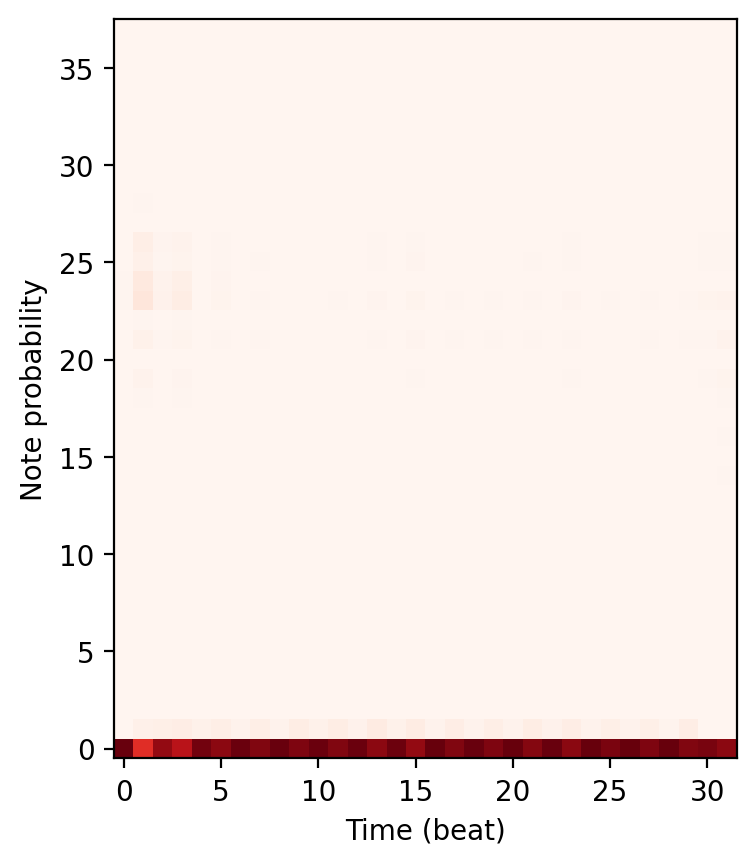

In [26]:
rl_net.generate_music_sequence(visualize_probs=True, title='pre_rl', length=32)

In [17]:
from IPython.display import Audio
from pretty_midi import PrettyMIDI

music = PrettyMIDI(midi_file='/Users/asaha/Documents/Stanford/projects/music_rl_output/music_rl_train/pre_rl4.mid')
waveform = music.fluidsynth()
Audio(waveform, rate=44100)

In [10]:
rl_net.train(num_steps=1000000, exploration_period=500000)

INFO:tensorflow:Evaluating initial model...
INFO:tensorflow:Evaluating model...
INFO:tensorflow:Training iteration 50000
INFO:tensorflow:	Reward for last 50000 steps: -256945.66480577082
INFO:tensorflow:		Music theory reward: -33570.057968144974
INFO:tensorflow:		Note RNN reward: -223375.60683763027
INFO:tensorflow:	Exploration probability is 0.9042382
INFO:tensorflow:Evaluating model...
INFO:tensorflow:Training iteration 100000
INFO:tensorflow:	Reward for last 50000 steps: -236636.04260102878
INFO:tensorflow:		Music theory reward: -20330.140697998697
INFO:tensorflow:		Note RNN reward: -216305.90190303326
INFO:tensorflow:	Exploration probability is 0.8084781999999999
INFO:tensorflow:Evaluating model...
Instructions for updating:
Use standard file APIs to delete files with this prefix.
INFO:tensorflow:Training iteration 150000
INFO:tensorflow:	Reward for last 50000 steps: -218217.4186887766
INFO:tensorflow:		Music theory reward: -10818.329271559174
INFO:tensorflow:		Note RNN reward: -20

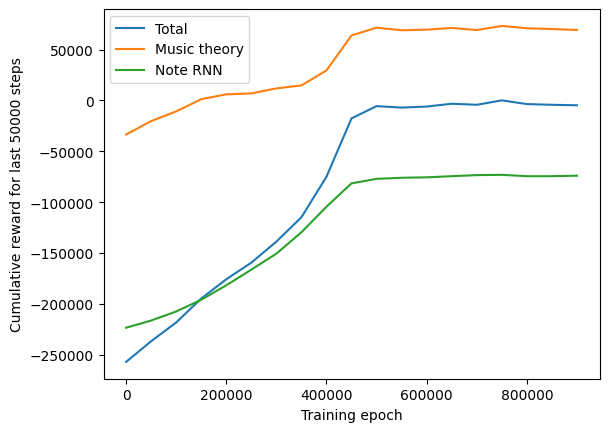

In [11]:
rl_net.plot_rewards()

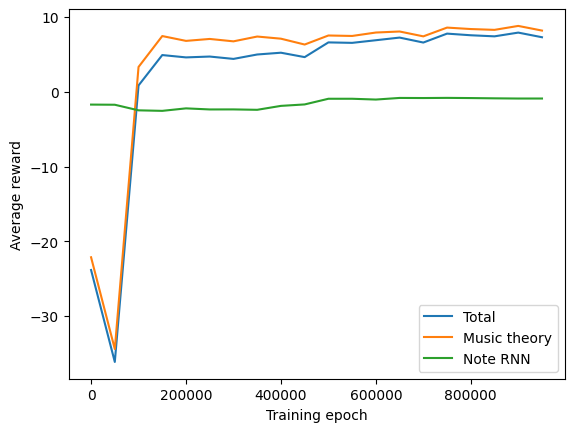

In [12]:
rl_net.plot_evaluation()

INFO:tensorflow:Priming with note 3
INFO:tensorflow:Generated sequence: [1, 14, 1, 0, 9, 1, 9, 1, 0, 21, 1, 9, 1, 9, 1, 0, 21, 1, 0, 9, 1, 14, 1, 0, 21, 1, 14, 1, 0, 9, 1, 0]
INFO:tensorflow:Wrote a melody to /Users/asaha/Documents/Stanford/projects/music_rl_output/music_rl_train
INFO:tensorflow:Visualizing note selection probabilities:


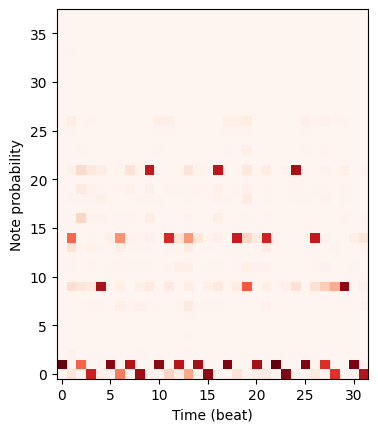

In [19]:
rl_net.generate_music_sequence(visualize_probs=True, title='post_rl')

In [20]:
music = PrettyMIDI(midi_file='/Users/asaha/Documents/Stanford/projects/music_rl_output/music_rl_train/post_rl2.mid')
waveform = music.fluidsynth()
Audio(waveform, rate=44100)

Changing working directory to: `/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21'
Processing `/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmp2l3kv613.ly'
Parsing...
/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmp2l3kv613.ly:56:5: error: unknown escaped string: `\RemoveEmptyStaffContext'
    
    \RemoveEmptyStaffContext
/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmp2l3kv613.ly:57:5: error: syntax error, unexpected \override, expecting '='
    
    \override VerticalAxisGroup #'remove-first = ##t
/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmp2l3kv613.ly:57:33: warning: deprecated: missing `.' in property path VerticalAxisGroup.remove-first
    \override VerticalAxisGroup 
                                #'remove-first = ##t
/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmp2l3kv613.ly:59:2: error: syntax error, unexpected '}'
 
 }
/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmp2l3kv613.ly:59:3: error: U

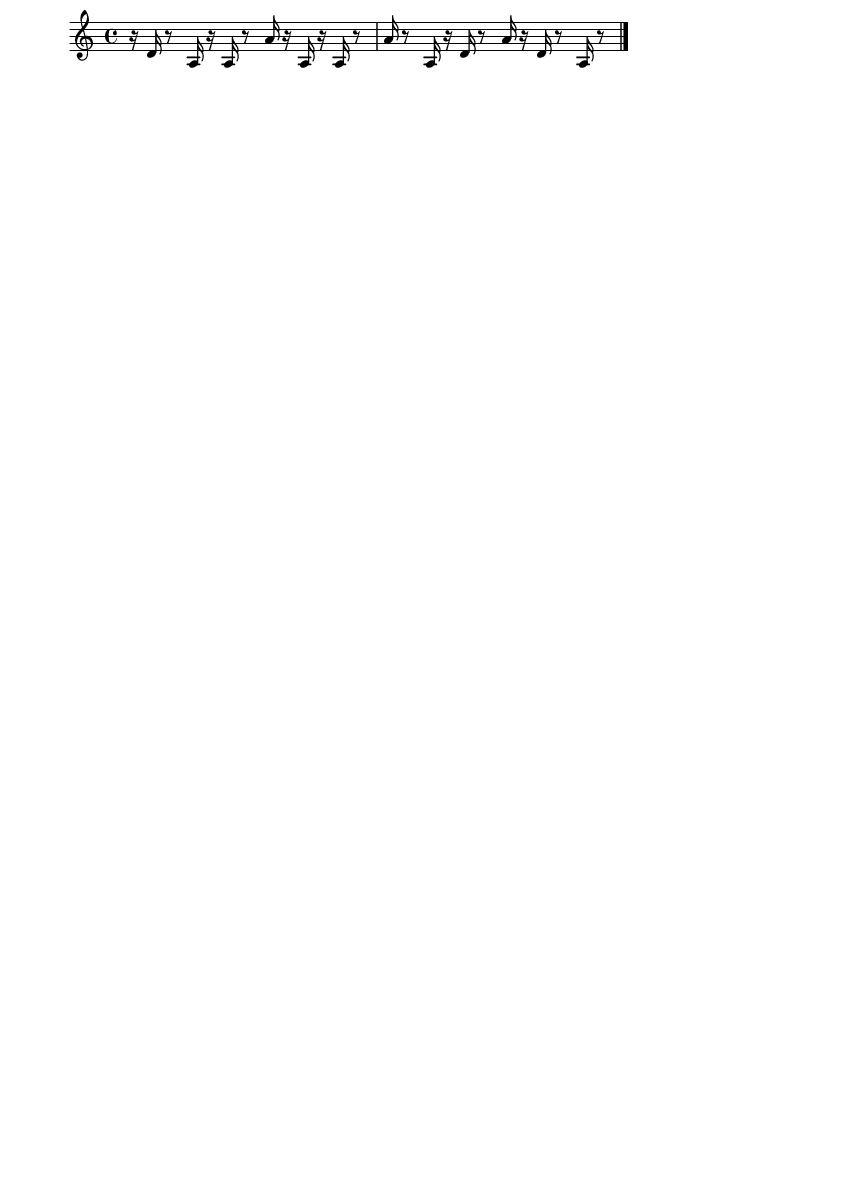

In [21]:
from music21 import converter
s = converter.parse('/Users/asaha/Documents/Stanford/projects/music_rl_output/music_rl_train/post_rl2.mid')
from IPython.display import Image
Image(filename=s.write('lily.png'))

In [22]:
rl_net.evaluate_music_theory_metrics(num_compositions=100)

INFO:tensorflow:Total compositions: 100.0
Total notes:3200.0
	Compositions starting with tonic: 5.0
	Compositions with unique highest note:27.0
	Compositions with unique lowest note:16.0
	Number of resolved leaps:18.0
	Number of double leaps:8.0
	Notes not in key:4.0
	Notes in motif:2317.0
	Notes in repeated motif:905.0
	Notes excessively repeated:0.0

	Percent compositions starting with tonic:0.05
	Percent compositions with unique highest note:0.27
	Percent compositions with unique lowest note:0.16
	Percent of leaps resolved:0.6923076923076923
	Percent notes not in key:0.00125
	Percent notes in motif:0.7240625
	Percent notes in repeated motif:0.2828125
	Percent notes excessively repeated:0.0

	Average autocorrelation of lag1:-0.4373510139024041
	Average autocorrelation of lag2:0.07896494529484503
	Average autocorrelation of lag3:0.1271237938099622

	Avg. num octave jumps per composition:0.07
	Avg. num sevenths per composition:0.03
	Avg. num fifths per composition:0.01
	Avg. num sixths

{'autocorrelation1': [-0.4817452233773532,
  -0.38690977961432504,
  -0.4777533935868135,
  -0.12887923000455617,
  -0.4098714953271028,
  -0.4084917023554604,
  -0.49168069013980326,
  -0.15820875910624357,
  -0.5012785822064884,
  -0.4572712330243587,
  -0.2760243543850678,
  -0.2545237253177047,
  -0.4817452233773532,
  -0.43991296026248633,
  -0.3825920369769705,
  -0.3665166788484184,
  -0.533897047705451,
  -0.5079114692839096,
  -0.4680269922879177,
  -0.45762077559721615,
  -0.40962923193532086,
  -0.5079114692839096,
  -0.46804755549311605,
  -0.35174847648067037,
  -0.4817452233773532,
  -0.35995684968741504,
  -0.4564569049103123,
  -0.4206581901223099,
  -0.3104537269963913,
  -0.4434619977521776,
  -0.4566637889973803,
  -0.4817452233773532,
  -0.46144610275067527,
  -0.3412745594885389,
  -0.49778721372116996,
  -0.22209276618323312,
  -0.43010794743429287,
  -0.5107451073661321,
  -0.4971106897984625,
  -0.46804755549311605,
  -0.4689931958043437,
  -0.46804755549311605,